In [1]:
# 📦 1. 환경 설정 및 필수 모듈 Import
# LangChain 및 AI 모델 관련 라이브러리
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langchain_core.runnables import RunnableConfig, RunnablePassthrough
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_teddynote.models import get_model_name, LLMs
from langchain_teddynote.messages import stream_graph, random_uuid
from langchain import hub
from langchain.retrievers.document_compressors import CohereRerank
from langchain_teddynote.graphs import visualize_graph
from rag.pdf import PDFRetrievalChain

# LangGraph 관련 라이브러리
from langgraph.graph import END, StateGraph, START
from langgraph.checkpoint.memory import MemorySaver

# 데이터 처리 및 표시용 라이브러리
import pandas as pd
import numpy as np
import json
import os
from typing import List, Literal, Annotated, Dict, Any, Optional
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()

# 최신 LLM 모델 이름 가져오기
MODEL_NAME = get_model_name(LLMs.GPT4)

print("✅ 환경 설정 및 필수 모듈 import 완료")
print(f"📱 사용 모델: {MODEL_NAME}")


✅ 환경 설정 및 필수 모듈 import 완료
📱 사용 모델: gpt-4o-mini


In [2]:
# 🔧 2. RAG 시스템 초기화
# LLM 및 임베딩 모델 초기화
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
embedding_model = OpenAIEmbeddings()

# 🔧 2. RAG 시스템 초기화
# LLM 및 임베딩 모델 초기화
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
embedding_model = OpenAIEmbeddings()

# Cohere 리랭커 우선 설정, 실패 시 Cross Encoder 사용
try:
    # 1. Cohere 리랭커 시도
    reranker = CohereRerank(
        cohere_api_key=os.getenv("COHERE_API_KEY"),
        top_n=5,
        model="rerank-multilingual-v3.0"  # 한국어 지원 모델
    )
    
    # API 테스트 (실제 사용 가능한지 확인)
    try:
        # 테스트용 더미 문서로 API 호출 테스트
        test_docs = [Document(page_content="test", metadata={})]
        test_result = reranker.compress_documents(test_docs, query="test")
        print("✅ Cohere 리랭커 설정 및 API 테스트 완료")
    except Exception as api_error:
        print(f"⚠️ Cohere API 테스트 실패: {api_error}")
        raise api_error  # Cross Encoder로 전환하기 위해 예외 발생
    
except Exception as e:
    print(f"⚠️ Cohere 리랭커 설정 실패: {e}")
    
    # 2. 대체 방안: Sentence Transformers Cross Encoder
    try:
        from sentence_transformers import CrossEncoder
        
        # Cross Encoder 모델 로드 (한국어 지원)
        cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
        
        def free_reranker(documents, query, top_n=5):
            """무료 Cross Encoder를 사용한 reranker"""
            if len(documents) <= top_n:
                return documents
                
            # 점수 계산
            pairs = [(query, doc.page_content) for doc in documents]
            scores = cross_encoder.predict(pairs)
            
            # 점수 기준으로 정렬
            doc_scores = list(zip(documents, scores))
            doc_scores.sort(key=lambda x: x[1], reverse=True)
            
            return [doc for doc, score in doc_scores[:top_n]]
        
        reranker = "free_cross_encoder"  # 대체 reranker로 설정
        print("✅ 무료 Cross Encoder reranker 설정 완료 (Cohere 대체)")
        
    except Exception as e2:
        print(f"⚠️ Cross Encoder 설정도 실패: {e2}")
        reranker = None
        print("⚠️ 리랭킹 기능 없이 진행합니다")

# 벡터스토어 리트리버 설정 (작물별 분리)
def setup_crop_specific_retriever(crop_name):
    """작물별 전용 벡터스토어 설정"""
    try:
        # 작물별 데이터 경로 설정
        if crop_name == "strawberry":
            data_paths = [
                {"path": "data/strawberry/딸기 재배 일정 통일 및 상세화.pdf", "crop": "strawberry"},
                {"path": "data/strawberry/딸기 재배 기술 정론(최신 교정).pdf", "crop": "strawberry"},
                {"path": "data/strawberry/딸기 재배 기술 총람 (최신 교정).pdf", "crop": "strawberry"},
                {"path": "data/strawberry/딸기 길라잡이.pdf", "crop": "strawberry"},
                {"path": "data/strawberry/딸기 농작업일정.pdf", "crop": "strawberry"},
                {"path": "data/strawberry/딸기 병해충 및 비료.pdf", "crop": "strawberry"},
                {"path": "data/strawberry/딸기 재배메뉴얼.pdf", "crop": "strawberry"},
                {"path": "data/strawberry/딸기 재배법.pdf", "crop": "strawberry"}
            ]
            persist_dir = "db/strawberry_vector"
        elif crop_name == "tomato":
            data_paths = [
                {"path": "data/tomato/토마토 반촉성재배 상세 일정 생성.pdf", "crop": "tomato"},
                {"path": "data/tomato/토마토 반촉성재배 기술 정론 (교정).pdf", "crop": "tomato"},
                {"path": "data/tomato/토마토 상업 재배 기술 총람 (교정).pdf", "crop": "tomato"},
                {"path": "data/tomato/토마토 농작업일정.pdf", "crop": "tomato"},
                {"path": "data/tomato/토마토 백과사전.pdf", "crop": "tomato"},
                {"path": "data/tomato/토마토 병해충 및 비료.pdf", "crop": "tomato"},
                {"path": "data/tomato/토마토 재배법.pdf", "crop": "tomato"}
            ]
            persist_dir = "db/tomato_vector"
        else:
            raise ValueError(f"지원되지 않는 작물: {crop_name}")

        # 파일 존재 확인
        valid_paths = [item for item in data_paths if os.path.exists(item["path"])]
        if not valid_paths:
            raise FileNotFoundError(f"⚠️ {crop_name} 데이터 파일을 찾을 수 없습니다.")

        print(f"📚 {crop_name} 전용 벡터스토어 생성 중...")
        print(f"   - 데이터 파일: {len(valid_paths)}개")
        print(f"   - 저장 위치: {persist_dir}")

        crop_data = PDFRetrievalChain(
            valid_paths,
            persist_dir=persist_dir,
            force_rebuild=False
        ).create_chain()

        print(f"✅ {crop_name} 전용 벡터스토어 사용")
        return crop_data.retriever

    except Exception as e:
        print(f"❌ {crop_name} 벡터스토어 생성 실패: {e}")
        raise e

def setup_all_crop_retrievers():
    """모든 작물의 벡터스토어 설정"""
    retrievers = {}
    
    for crop in ["strawberry", "tomato"]:
        try:
            retrievers[crop] = setup_crop_specific_retriever(crop)
        except Exception as e:
            print(f"❌ {crop} 리트리버 설정 실패: {e}")
            retrievers[crop] = None
    
    return retrievers

# 작물별 벡터스토어 설정
try:
    crop_retrievers = setup_all_crop_retrievers()
    print("✅ 작물별 벡터스토어 초기화 완료")
except Exception as e:
    print(f"❌ 벡터스토어 초기화 실패: {e}")
    raise e

print("✅ RAG 시스템 초기화 완료")


C:\Users\user\AppData\Local\Temp\ipykernel_27152\1955213355.py:14: LangChainDeprecationWarning: The class `CohereRerank` was deprecated in LangChain 0.0.30 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-cohere package and should be used instead. To use it run `pip install -U :class:`~langchain-cohere` and import as `from :class:`~langchain_cohere import CohereRerank``.
  reranker = CohereRerank(


⚠️ Cohere API 테스트 실패: status_code: 429, body: {'id': '6792ae02-d7e8-4e4d-9b37-f4a1ec1a914d', 'message': "You are using a Trial key, which is limited to 1000 API calls / month. You can continue to use the Trial key for free or upgrade to a Production key with higher rate limits at 'https://dashboard.cohere.com/api-keys'. Contact us on 'https://discord.gg/XW44jPfYJu' or email us at support@cohere.com with any questions"}
⚠️ Cohere 리랭커 설정 실패: status_code: 429, body: {'id': '6792ae02-d7e8-4e4d-9b37-f4a1ec1a914d', 'message': "You are using a Trial key, which is limited to 1000 API calls / month. You can continue to use the Trial key for free or upgrade to a Production key with higher rate limits at 'https://dashboard.cohere.com/api-keys'. Contact us on 'https://discord.gg/XW44jPfYJu' or email us at support@cohere.com with any questions"}
✅ 무료 Cross Encoder reranker 설정 완료 (Cohere 대체)
📚 strawberry 전용 벡터스토어 생성 중...
   - 데이터 파일: 8개
   - 저장 위치: db/strawberry_vector


c:\Users\user\Documents\langchain-kr\calendar format re\rag\pdf.py:108: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embedding_model = OpenAIEmbeddings(


🔁 기존 벡터 DB 로드 중: db/strawberry_vector


c:\Users\user\Documents\langchain-kr\calendar format re\rag\pdf.py:115: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(


✅ strawberry 전용 벡터스토어 사용
📚 tomato 전용 벡터스토어 생성 중...
   - 데이터 파일: 7개
   - 저장 위치: db/tomato_vector
🔁 기존 벡터 DB 로드 중: db/tomato_vector
✅ tomato 전용 벡터스토어 사용
✅ 작물별 벡터스토어 초기화 완료
✅ RAG 시스템 초기화 완료


In [3]:
# 📍 2-1. 경작지 위치 관리 기능
from gps_class import GeocodingManager

# 🔧 헬퍼 함수들 (하드코딩 제거용)
def extract_month_number(month_str):
    """월 문자열에서 숫자 추출 (범용 처리)"""
    import re
    numbers = re.findall(r'\d+', str(month_str))
    if numbers:
        return int(numbers[0])
    return 999

def extract_months(period_str):
    """기간 문자열에서 월 추출 (개선됨)"""
    months = []
    for i in range(1, 13):
        if f"{i}월" in period_str or str(i) in period_str:
            months.append(i)
    return months

def create_improved_detail_prompt(schedule, crop_name, context, location_context):
    """개선된 세분화 프롬프트 생성"""
    task_name = schedule.get("task", "")
    period = schedule.get("period", "")
    
    return f"""
당신은 농업 전문가입니다. 주어진 문서에서 {crop_name}의 '{task_name}' 작업을 분석하여 월별로 세분화하세요.

{location_context}

## 핵심 요구사항:

### 1. 기간 엄격 준수 (중요!)
메인 작업 기간 '{period}' 내에서만 월별 작업을 생성하세요:
- 기간 밖의 월에는 작업 생성 금지
- 연속성 있는 작업 흐름 유지

### 2. 논리적 연결성
각 월별 작업이 이전 월의 작업과 논리적으로 연결되도록 구성하세요.

## 분석 요청사항:

### 1. 작업 특성 분석
문서를 분석하여 '{task_name}' 작업의 특성을 파악하세요:
- 이 작업이 {crop_name} 재배에서 어떤 역할을 하는가?
- 언제 시작하고 언제 끝나는가?
- 어떤 조건과 환경이 필요한가?

### 2. 월별 세분화 계획
작업의 전체 기간을 월별로 나누어 구체적인 작업을 정의하세요:
- 각 월에 수행할 세부 작업은 무엇인가?
- 필요한 도구, 자재, 환경 조건은 무엇인가?
- 주의사항과 작업 방법은 무엇인가?

### 3. 시간순 정렬
월별 작업을 시간순으로 정렬하세요:
- 재배 일정 순서를 먼저 배열한 후에 세부일정 순서를 배열하세요.
- 시작 월부터 끝 월까지 순서대로 배열
- 연간 순환(11월→12월→1월→2월)을 고려
- 각 월별 작업이 논리적으로 연결되는지 확인

### 4. 현실성 검증
세분화된 작업이 현실적인지 검증하세요:
- 작물의 생육 주기에 맞는가?
- 기후 조건을 고려했는가?
- 각 월별 작업의 기간이 적절한가?

## 출력 형식:
다음 JSON 형식으로 정확히 출력해주세요:
{{
  "detailed_tasks": [
    {{
      "task_name": "자동_생성된_세부_작업명",
      "month": "해당_월",
      "subtask": "구체적인_세부작업",
      "period": "해당_월",
      "description": "해당 월의 구체적인 작업 설명",
      "methods": ["작업방법1", "작업방법2", "작업방법3"],
      "precautions": ["주의사항1", "주의사항2", "주의사항3"],
      "tools_materials": ["도구1", "자재1", "장비1"],
      "environmental_conditions": "온도 범위, 습도 범위, 기타 환경조건",
      "frequency": "작업 빈도",
      "duration": "작업 소요시간"
    }}
  ]
}}

## 주의사항:
- 문서에 명시된 정보를 바탕으로 분석하세요
- 작물의 생육 특성을 고려하여 현실적인 작업 내용을 구성하세요
- **중요**: 재배 일정 순서를 먼저 배열한 후에 세부일정을 시기순으로 정렬하세요.
- **중요**: 월별 작업을 시기순으로 정렬하여 출력하세요
- **중요**: 작업명을 '{task_name}'과 구분되는 구체적인 이름으로 변환하세요
- **중요**: 현실적인 기간과 작업 내용으로 구성하세요
- **절대 금지**: 메인 기간 '{period}' 밖의 월에 작업 생성

문서 내용:
{context}
"""

def post_process_llm_response(task_details, main_task, main_period):
    """LLM 응답을 후처리하여 일관성 확보"""
    processed_tasks = []
    period_months = extract_months(main_period)
    
    for task in task_details:
        # 1. main_task 필드 추가 (원본 참조용)
        task["main_task"] = main_task
        
        # 2. 기간 검증
        task_month = task.get("month", "")
        month_num = extract_month_number(task_month)
        
        if month_num in period_months:
            # 3. 작업명이 너무 일반적이면 구체화
            if task.get("task_name") == main_task:
                # LLM이 작업명을 변환하지 않은 경우, subtask를 사용
                task["task_name"] = task.get("subtask", main_task)
            
            processed_tasks.append(task)
        else:
            print(f"⚠️ 제외: {task.get('task_name')} ({task_month}) - 기간 밖")
    
    return processed_tasks

def extract_keywords_auto(task, details):
    """자동 키워드 추출 (하드코딩 제거)"""
    keywords = set()
    
    # 작업명에서 키워드 추출
    if task:
        keywords.add(task)
    
    # 상세내용에서 주요 단어 추출
    if details:
        import re
        words = re.findall(r'[\w가-힣]+', details)
        keywords.update([word for word in words if len(word) > 1])
    
    return list(keywords)

def get_main_schedule_order(schedules):
    """메인 일정표에서 작업 순서 추출 (하드코딩 제거)"""
    order = {}
    for i, schedule in enumerate(schedules):
        task = schedule.get('task', '')
        if task:
            order[task] = i + 1
    return order

def get_annual_cycle_info(schedules):
    """메인 일정표에서 연간 순서 정보 추출"""
    cycle_info = {
        'has_cross_year': False,
        'start_month': None,
        'end_month': None
    }
    
    for schedule in schedules:
        period = schedule.get('period', '')
        if '~' in period and ('12월' in period or '1월' in period or '2월' in period):
            cycle_info['has_cross_year'] = True
            break
    
    return cycle_info

# 사용자 경작지 정보를 저장할 전역 변수
USER_FARM_INFO = None

# 지오코딩 매니저 인스턴스 생성
try:
    geo_manager = GeocodingManager()
    print("✅ GeocodingManager 인스턴스 생성 완료")
except Exception as e:
    print(f"❌ GeocodingManager 초기화 실패: {e}")
    geo_manager = None

def get_farm_location():
    """현재 설정된 경작지 위치 정보를 반환하는 함수"""
    global USER_FARM_INFO
    return USER_FARM_INFO

def get_farm_info():
    """현재 설정된 경작지 정보를 반환하는 함수"""
    global USER_FARM_INFO
    if USER_FARM_INFO is None:
        print("⚠️ 경작지 정보가 설정되지 않았습니다.")
    return USER_FARM_INFO

def set_farm_info(farm_data):
    """경작지 정보를 직접 설정하는 함수"""
    global USER_FARM_INFO
    USER_FARM_INFO = farm_data
    print(f"✅ 경작지 정보가 설정되었습니다: {farm_data.get('road_address', 'N/A')}")

def clear_farm_info():
    """경작지 정보를 초기화하는 함수"""
    global USER_FARM_INFO
    USER_FARM_INFO = None
    print("✅ 경작지 정보가 초기화되었습니다.")

def get_location_context():
    """현재 경작지 위치 정보를 AI 모델에서 사용할 수 있는 구조화된 텍스트로 변환"""
    farm_info = get_farm_info()
    
    if not farm_info:
        return "경작지 위치 정보가 설정되지 않았습니다."
    
    context = f"""
📍 경작지 위치 정보:
- 주소: {farm_info.get('road_address', 'N/A')}
- 법정동: {farm_info.get('legal_address', 'N/A')}
- 좌표: ({farm_info.get('longitude')}, {farm_info.get('latitude')})
"""
    return context.strip()

def setup_farm_location():
    """사용자가 직접 주소를 입력하여 경작지 위치를 설정하는 함수"""
    global USER_FARM_INFO
    
    if not geo_manager:
        print("❌ 지오코딩 매니저가 초기화되지 않았습니다.")
        return None
    
    print("🌱 경작지 위치 설정")
    print("=" * 50)
    
    while True:
        try:
            print("\n📍 경작지 주소를 입력해주세요:")
            print("예시: 서울시 강남구 테헤란로 123, 전라남도 순천시 중앙로 255")
            print("      또는: 순천대학교, 서울시청, 강남역 등")
            
            user_address = input("\n주소: ").strip()
            
            if not user_address:
                print("❌ 주소를 입력해주세요.")
                continue
            
            print(f"\n🔍 입력된 주소: {user_address}")
            print("📍 주소를 좌표로 변환하고 정확한 주소를 확인하는 중...")
            
            # 지오코딩 + 리버스 지오코딩 통합 처리
            result = geo_manager.get_final_address(user_address, verbose=False)
            
            if result:
                print("\n✅ 주소 변환 완료!")
                print("=" * 50)
                print("📋 확인된 정보:")
                print(f"   입력 주소: {result['input_address']}")
                print(f"   좌표: {result['coordinates']['longitude']}, {result['coordinates']['latitude']}")
                print(f"   도로명 주소: {result['final_address']['road_address']}")
                print(f"   법정동 주소: {result['final_address']['legal_address']}")
                print("=" * 50)
                
                # 사용자 확인
                confirm = input("\n이 위치가 맞나요? (y/n): ").lower().strip()
                if confirm in ['y', 'yes', '예', 'ㅇ']:
                    USER_FARM_INFO = {
                        'longitude': result['coordinates']['longitude'],
                        'latitude': result['coordinates']['latitude'],
                        'road_address': result['final_address']['road_address'],
                        'legal_address': result['final_address']['legal_address'],
                        'full_address': result['final_address']['full_address'],
                        'user_input': user_address,
                        'raw_data': result
                    }
                    
                    print("\n🎉 경작지 위치 설정 완료!")
                    print(f"📍 설정된 위치: {USER_FARM_INFO['road_address']}")
                    print(f"📍 좌표: {USER_FARM_INFO['longitude']}, {USER_FARM_INFO['latitude']}")
                    
                    return USER_FARM_INFO
                else:
                    print("다시 입력해주세요.")
                    continue
            else:
                print("❌ 주소를 찾을 수 없습니다. 다시 시도해주세요.")
                continue
                
        except KeyboardInterrupt:
            print("\n\n❌ 사용자가 취소했습니다.")
            break
        except Exception as e:
            print(f"❌ 오류 발생: {e}")
            retry = input("다시 시도하시겠습니까? (y/n): ").lower().strip()
            if retry not in ['y', 'yes', '예', 'ㅇ']:
                break
    
    return None

print("✅ 경작지 위치 관리 모듈이 로드되었습니다.")

✅ GeocodingManager 클래스가 정의되었습니다.
✅ GeocodingManager 인스턴스 생성 완료
✅ 경작지 위치 관리 모듈이 로드되었습니다.


In [4]:
# 📊 3. LangGraph State 정의 및 Pydantic 모델

# 재배 일정 정보를 위한 Pydantic 모델
class ScheduleItem(BaseModel):
    """개별 재배 일정 항목"""
    period: str = Field(description="재배 기간 (예: 3월~5월, 6월)")
    task: str = Field(description="재배 작업명 (예: 육묘기, 정식기, 수확기)")
    details: str = Field(description="상세 내용 및 설명")

class DetailedTaskItem(BaseModel):
    """세분화된 재배 작업 항목 (월별 세분화)"""
    task_name: str = Field(description="작업명 (예: 육묘기)")
    month: str = Field(description="월 (예: 3월, 4월)")
    subtask: str = Field(description="세부 작업명 (예: 파종, 발아관리)")
    period: str = Field(description="작업 기간")
    description: str = Field(description="작업 설명")
    methods: List[str] = Field(description="구체적인 작업 방법들")
    precautions: List[str] = Field(description="주의사항들")
    tools_materials: List[str] = Field(description="필요한 도구/자재")
    environmental_conditions: str = Field(description="환경 조건 (온도, 습도 등)")
    frequency: str = Field(description="작업 빈도")
    duration: str = Field(description="작업 소요 시간")

class ScheduleList(BaseModel):
    """재배 일정 목록"""
    schedules: List[ScheduleItem] = Field(description="재배 일정 목록")

class DetailedTaskList(BaseModel):
    """세분화된 작업 목록"""
    detailed_tasks: List[DetailedTaskItem] = Field(description="세분화된 작업 목록")

# LangGraph State 정의
class ScheduleState(TypedDict):
    """재배 일정표 생성 워크플로우의 상태"""
    crop: Annotated[str, "작물명 (strawberry 또는 tomato)"]
    documents: Annotated[List[Document], "검색된 문서"]
    schedules: Annotated[List[dict], "추출된 일정 목록"]
    detailed_tasks: Annotated[List[dict], "세분화된 작업 목록"]
    overlaps: Annotated[List[dict], "겹치는 일정 목록"]
    main_df: Annotated[Any, "메인 일정표 DataFrame"]
    detailed_df: Annotated[Any, "세분화된 작업 DataFrame"]
    overlap_df: Annotated[Any, "겹침 일정표 DataFrame"]
    status: Annotated[str, "처리 상태"]
    error_message: Annotated[Optional[str], "에러 메시지"]

print("✅ LangGraph State 및 Pydantic 모델 정의 완료 (세분화 기능 포함)")


✅ LangGraph State 및 Pydantic 모델 정의 완료 (세분화 기능 포함)


In [5]:
# 🔍 4. 노드 함수 구현 (위치 정보 활용 버전 + 작업 세분화)

def get_enhanced_query(crop_name, location_context):
    """작물별 특화된 검색 쿼리 생성 (하드코딩 제거)"""
    # 기본 쿼리 (범용)
    base_query = f"{crop_name} 재배 일정 월별 농작업 일정표"
    
    # 작물명을 기반으로 한 일반적인 키워드
    specific_query = f"{crop_name} 재배 기술 월별 작업 일정"
    
    return f"{base_query} {specific_query} {location_context}"

def retrieve_schedule_node(state: ScheduleState) -> ScheduleState:
    """재배 일정 관련 문서를 검색하는 노드 (위치 정보 활용)"""
    print(f"==== [RETRIEVE SCHEDULE] {state['crop']} ====")
    
    try:
        # 작물별 검색 쿼리 생성 (개선된 버전)
        crop_name = "딸기" if state['crop'] == "strawberry" else "토마토"
        
        # 위치 정보가 있으면 쿼리에 추가
        location_context = get_location_context()
        if location_context and "경작지 위치 정보가 설정되지 않았습니다" not in location_context:
            query = get_enhanced_query(crop_name, location_context)
            print(f"📍 위치 정보가 포함된 검색 쿼리 사용")
        else:
            query = get_enhanced_query(crop_name, "")
        
        print(f"🔍 검색 쿼리: {query}")
        
        # 벡터스토어에서 문서 검색 (작물별 전용 벡터스토어 사용)
        crop_retriever = crop_retrievers.get(state['crop'])
        if not crop_retriever:
            raise ValueError(f"{state['crop']} 리트리버가 설정되지 않았습니다.")
        
        documents = crop_retriever.invoke(query)
        
        # 리랭커가 있을 경우 사용
        if reranker:
            try:
                if reranker == "free_cross_encoder":
                    # 무료 Cross Encoder 사용
                    reranked_documents = free_reranker(documents, query, top_n=5)
                    print(f"📚 검색된 문서 수: {len(documents)} → Cross Encoder 리랭킹 후: {len(reranked_documents)}")
                else:
                    # 기존 Cohere 리랭커 사용
                    reranked_documents = reranker.compress_documents(
                        documents,
                        query=query
                    )
                    print(f"📚 검색된 문서 수: {len(documents)} → 리랭킹 후: {len(reranked_documents)}")
                
                documents = reranked_documents
            except Exception as e:
                print(f"⚠️ 리랭킹 실패: {e}")
                documents = documents[:10]  # 상위 10개만 선택
        else:
            documents = documents[:10]  # 상위 10개만 선택
            print(f"📚 검색된 문서 수: {len(documents)} (리랭킹 없음)")
        
        return {
            **state,
            "documents": documents,
            "status": "retrieved"
        }
        
    except Exception as e:
        print(f"❌ 문서 검색 실패: {e}")
        return {
            **state,
            "documents": [],
            "status": "error",
            "error_message": f"문서 검색 실패: {str(e)}"
        }

def validate_and_fix_schedule(schedules, crop_name):
    """일정표 검증 및 수정 (하드코딩 제거)"""
    # 하드코딩된 검증 로직을 제거하고 LLM이 생성한 일정을 그대로 사용
    # LLM 프롬프트에서 현실적인 기간을 생성하도록 유도
    return schedules

def extract_schedule_node(state: ScheduleState) -> ScheduleState:
    """검색된 문서에서 재배 일정을 추출하는 노드 (위치 정보 활용)"""
    print(f"==== [EXTRACT SCHEDULE] {state['crop']} ====")
    
    try:
        documents = state["documents"]
        if not documents:
            return {
                **state,
                "schedules": [],
                "status": "error",
                "error_message": "검색된 문서가 없습니다"
            }
        
        # 문서 내용을 컨텍스트로 변환
        context = "\n\n".join([
            f"문서 {i+1}: {doc.page_content}\n출처: {doc.metadata.get('source', 'Unknown')}"
            for i, doc in enumerate(documents)
        ])
        
        # LLM 프롬프트 생성 (위치 정보 포함, 하드코딩 제거)
        crop_name = "딸기" if state['crop'] == "strawberry" else "토마토"
        location_context = get_location_context()
        
        prompt = f"""
당신은 농업 전문가입니다. 주어진 문서에서 {crop_name}의 재배 일정을 분석하여 추출하세요.

{location_context}

## 분석 요청사항:

### 1. 작물 생육 특성 파악
문서를 분석하여 {crop_name}의 생육 특성을 파악하세요:
- 재배 일정의 첫 작업은 무엇인가요?
- 재배 시작 시점은 언제인가요?
- 각 재배 단계는 어떤 순서로 진행되나요?
- 각 단계의 기간은 얼마나 되나요?

### 2. 논리적 순서 추론
작물의 생육 특성을 바탕으로 논리적 순서를 추론하세요:
- 파종이 먼저 와야 하는지, 아니면 다른 작업이 먼저 와야 하는지
- 각 단계가 이전 단계의 결과물을 필요로 하는지
- 전체 재배 과정이 논리적으로 연결되는지

### 3. 시간순 정렬
문서에서 찾은 각 재배 단계를 시간순으로 정렬하세요:
- 시작 시점이 빠른 순서대로 배열
- 겹치는 기간이 있다면 모두 포함
- 연간 순환(11월→12월→1월→2월)을 고려

### 4. 현실성 검증
추출한 일정이 현실적인지 검증하세요:
- 작물의 생육 주기에 맞는지
- 기후 조건을 고려했는지
- 각 단계의 기간이 적절한지

## 출력 형식:
다음 JSON 형식으로 정확히 출력해주세요:
{{
  "schedules": [
    {{
      "period": "3월~5월",
      "task": "육묘기",
      "details": "육묘 상자에 파종하고 온실에서 관리"
    }},
    {{
      "period": "6월",
      "task": "정식기",
      "details": "본밭에 정식하고 지주 설치"
    }}
  ]
}}

## 주의사항:
- **중요**: 위의 단계를 순서대로 실행하세요.
- 문서에 명시된 정보를 바탕으로 분석하세요
- 작물의 생육 특성을 고려하여 현실적인 기간을 설정하세요
- **중요**: 모든 재배 일정을 포함하세요
- **중요**: 재배 일정의 순서에 맞게 정렬하여 출력하세요

문서 내용:
{context}
"""
        
        # LLM 호출
        response = llm.invoke(prompt)
        response_text = response.content
        
        print(f"🤖 LLM 응답 길이: {len(response_text)} 문자")
        
        # JSON 파싱 시도
        try:
            # JSON 부분만 추출
            start_idx = response_text.find('{')
            end_idx = response_text.rfind('}') + 1
            
            if start_idx != -1 and end_idx != -1:
                json_text = response_text[start_idx:end_idx]
                parsed_data = json.loads(json_text)
                
                schedules = parsed_data.get("schedules", [])
                
                # 검증 및 수정 로직 적용
                crop_name = "딸기" if state['crop'] == "strawberry" else "토마토"
                schedules = validate_and_fix_schedule(schedules, crop_name)
                
                # 메인 일정을 시기순으로 정렬 (하드코딩 제거)
                def get_schedule_start_month(schedule):
                    """일정의 시작 월을 추출 (범용 처리)"""
                    period = schedule.get("period", "")
                    return extract_month_number(period)
                
                # 메인 일정을 시작 월 순서로 정렬
                # schedules.sort(key=get_schedule_start_month)
                
                # print(f"✅ 일정 추출 완료: {len(schedules)}개 항목 (시기순 정렬)")
                
                return {
                    **state,
                    "schedules": schedules,
                    "status": "extracted"
                }
            else:
                raise ValueError("JSON 형식을 찾을 수 없습니다")
                
        except json.JSONDecodeError as e:
            print(f"❌ JSON 파싱 실패: {e}")
            print(f"응답 내용: {response_text[:500]}...")
            
            # 대체 방법: 간단한 파싱 시도
            schedules = []
            lines = response_text.split('\n')
            current_schedule = {}
            
            for line in lines:
                line = line.strip()
                if 'period' in line.lower() or '기간' in line:
                    if current_schedule:
                        schedules.append(current_schedule)
                    current_schedule = {"period": "", "task": "", "details": ""}
                elif 'task' in line.lower() or '작업' in line:
                    pass  # 다음 라인에서 처리
                elif line and not line.startswith('{') and not line.startswith('}'):
                    if not current_schedule.get("period"):
                        current_schedule["period"] = line
                    elif not current_schedule.get("task"):
                        current_schedule["task"] = line
                    else:
                        current_schedule["details"] = line
            
            if current_schedule:
                schedules.append(current_schedule)
            
            print(f"⚠️ 대체 파싱으로 {len(schedules)}개 항목 추출")
            
            return {
                **state,
                "schedules": schedules,
                "status": "extracted_fallback"
            }
        
    except Exception as e:
        print(f"❌ 일정 추출 실패: {e}")
        return {
            **state,
            "schedules": [],
            "status": "error",
            "error_message": f"일정 추출 실패: {str(e)}"
        }

def detail_tasks_node(state: ScheduleState) -> ScheduleState:
    """각 작업을 월별로 세분화하여 상세 정보를 추출하는 노드 (개선됨)"""
    print(f"==== [DETAIL TASKS] {state['crop']} ====")
    
    try:
        schedules = state["schedules"]
        documents = state["documents"]
        
        if not schedules:
            return {
                **state,
                "detailed_tasks": [],
                "status": "no_tasks_to_detail"
            }
        
        # 메인 일정을 시작 월 순서로 정렬
        def get_schedule_start_month(schedule):
            """일정의 시작 월을 추출 (범용 처리)"""
            period = schedule.get("period", "")
            return extract_month_number(period)
        
        sorted_schedules = sorted(schedules, key=get_schedule_start_month)
        
        # 문서 내용을 컨텍스트로 변환
        context = "\n\n".join([
            f"문서 {i+1}: {doc.page_content}\n출처: {doc.metadata.get('source', 'Unknown')}"
            for i, doc in enumerate(documents)
        ])
        
        # 각 작업별로 월별 세분화된 정보 추출
        detailed_tasks = []
        crop_name = "딸기" if state['crop'] == "strawberry" else "토마토"
        location_context = get_location_context()
        
        for schedule in sorted_schedules:  # 정렬된 순서로 처리
            task_name = schedule.get("task", "")
            period = schedule.get("period", "")
            
            if not task_name:
                continue
            
            print(f"🔍 {task_name} 작업을 월별로 세분화 중...")
            
            # 개선된 프롬프트 생성
            detail_prompt = create_improved_detail_prompt(schedule, crop_name, context, location_context)
            
            # LLM 호출
            response = llm.invoke(detail_prompt)
            response_text = response.content
            
            # JSON 파싱 및 후처리
            try:
                start_idx = response_text.find('{')
                end_idx = response_text.rfind('}') + 1
                
                if start_idx != -1 and end_idx != -1:
                    json_text = response_text[start_idx:end_idx]
                    parsed_data = json.loads(json_text)
                    
                    task_details = parsed_data.get("detailed_tasks", [])
                    
                    # 후처리: 검증 및 일관성 확보
                    processed_tasks = post_process_llm_response(task_details, task_name, period)
                    
                    # 월별 정렬
                    processed_tasks.sort(key=lambda x: extract_month_number(x.get("month", "")))
                    
                    detailed_tasks.extend(processed_tasks)
                    print(f"✅ {task_name} 월별 세분화 완료: {len(processed_tasks)}개 월별 작업")
                    
                else:
                    print(f"⚠️ {task_name} JSON 파싱 실패")
                    
            except json.JSONDecodeError as e:
                print(f"❌ {task_name} JSON 파싱 실패: {e}")
                continue
        
        # 전체 작업을 월별로 최종 정렬
        detailed_tasks.sort(key=lambda x: extract_month_number(x.get("month", "")))
        
        print(f"✅ 전체 작업 월별 세분화 완료: {len(detailed_tasks)}개 월별 작업")
        
        return {
            **state,
            "detailed_tasks": detailed_tasks,
            "status": "detailed"
        }
        
    except Exception as e:
        print(f"❌ 작업 세분화 실패: {e}")
        return {
            **state,
            "detailed_tasks": [],
            "status": "error",
            "error_message": f"작업 세분화 실패: {str(e)}"
        }

print("✅ 노드 함수 구현 완료 (위치 정보 활용 + 작업 세분화 버전)")

✅ 노드 함수 구현 완료 (위치 정보 활용 + 작업 세분화 버전)


In [6]:
# 🔄 5. 겹침 감지 및 DataFrame 생성 노드 (세분화 기능 포함)

def detect_overlap_node(state: ScheduleState) -> ScheduleState:
    """겹치는 일정을 감지하는 노드"""
    print(f"==== [DETECT OVERLAP] {state['crop']} ====")
    
    try:
        schedules = state["schedules"]
        if not schedules:
            return {
                **state,
                "overlaps": [],
                "status": "no_overlaps"
            }
        
        overlaps = []
        
        # 월별로 일정을 그룹화
        monthly_schedules = {}
        
        for schedule in schedules:
            period = schedule.get("period", "")
            task = schedule.get("task", "")
            
            # 월 추출 (간단한 패턴 매칭)
            months = []
            if "1월" in period or "1" in period:
                months.append(1)
            if "2월" in period or "2" in period:
                months.append(2)
            if "3월" in period or "3" in period:
                months.append(3)
            if "4월" in period or "4" in period:
                months.append(4)
            if "5월" in period or "5" in period:
                months.append(5)
            if "6월" in period or "6" in period:
                months.append(6)
            if "7월" in period or "7" in period:
                months.append(7)
            if "8월" in period or "8" in period:
                months.append(8)
            if "9월" in period or "9" in period:
                months.append(9)
            if "10월" in period or "10" in period:
                months.append(10)
            if "11월" in period or "11" in period:
                months.append(11)
            if "12월" in period or "12" in period:
                months.append(12)
            
            # 각 월에 일정 추가
            for month in months:
                if month not in monthly_schedules:
                    monthly_schedules[month] = []
                monthly_schedules[month].append({
                    "period": period,
                    "task": task,
                    "details": schedule.get("details", "")
                })
        
        # 겹치는 월 찾기
        for month, tasks in monthly_schedules.items():
            if len(tasks) > 1:
                overlap_info = {
                    "month": month,
                    "period": f"{month}월",
                    "tasks": tasks,
                    "task1": tasks[0]["task"],
                    "task2": tasks[1]["task"] if len(tasks) > 1 else "",
                    "note": f"{month}월에 {len(tasks)}개 작업이 겹침"
                }
                overlaps.append(overlap_info)
        
        print(f"🔍 겹치는 일정 감지: {len(overlaps)}개")
        
        return {
            **state,
            "overlaps": overlaps,
            "status": "overlaps_detected"
        }
        
    except Exception as e:
        print(f"❌ 겹침 감지 실패: {e}")
        return {
            **state,
            "overlaps": [],
            "status": "error",
            "error_message": f"겹침 감지 실패: {str(e)}"
        }

def create_dataframe_node(state: ScheduleState) -> ScheduleState:
    """DataFrame을 생성하는 노드 (세분화 기능 포함)"""
    print(f"==== [CREATE DATAFRAME] {state['crop']} ====")
    
    try:
        schedules = state["schedules"]
        detailed_tasks = state["detailed_tasks"]
        overlaps = state["overlaps"]
        
        # 메인 일정표 DataFrame 생성
        if schedules:
            main_data = []
            for schedule in schedules:
                main_data.append({
                    "기간": schedule.get("period", ""),
                    "작업명": schedule.get("task", ""),
                    "상세내용": schedule.get("details", "")
                })
            
            main_df = pd.DataFrame(main_data)
            
            # 월 순서로 정렬 (하드코딩 제거)
            # 정렬을 위한 임시 컬럼 추가
            #main_df['sort_key'] = main_df['기간'].apply(extract_month_number)
            #main_df = main_df.sort_values('sort_key').drop('sort_key', axis=1)
            
        else:
            main_df = pd.DataFrame(columns=["기간", "작업명", "상세내용"])
        
        # 세분화된 작업 DataFrame 생성 (월별 세분화)
        if detailed_tasks:
            detailed_data = []
            for task in detailed_tasks:
                detailed_data.append({
                    "작업명": task.get("task_name", ""),
                    "월": task.get("month", ""),
                    "세부작업": task.get("subtask", ""),
                    "기간": task.get("period", ""),
                    "설명": task.get("description", ""),
                    "작업방법": ", ".join(task.get("methods", [])),
                    "주의사항": ", ".join(task.get("precautions", [])),
                    "도구/자재": ", ".join(task.get("tools_materials", [])),
                    "환경조건": task.get("environmental_conditions", ""),
                    "작업빈도": task.get("frequency", ""),
                    "소요시간": task.get("duration", "")
                })
            
            detailed_df = pd.DataFrame(detailed_data)
            
            # 월 순서로 정렬 (하드코딩 제거)
            detailed_df['sort_key'] = detailed_df['월'].apply(extract_month_number)
            detailed_df = detailed_df.sort_values('sort_key').drop('sort_key', axis=1)
        else:
            detailed_df = pd.DataFrame(columns=[
                "작업명", "월", "세부작업", "기간", "설명", "작업방법", 
                "주의사항", "도구/자재", "환경조건", "작업빈도", "소요시간"
            ])
        
        # 겹침 일정표 DataFrame 생성
        if overlaps:
            overlap_data = []
            for overlap in overlaps:
                overlap_data.append({
                    "기간": overlap.get("period", ""),
                    "작업1": overlap.get("task1", ""),
                    "작업2": overlap.get("task2", ""),
                    "비고": overlap.get("note", "")
                })
            
            overlap_df = pd.DataFrame(overlap_data)
        else:
            overlap_df = pd.DataFrame(columns=["기간", "작업1", "작업2", "비고"])
        
        print(f"📊 DataFrame 생성 완료:")
        print(f"   - 메인 일정표: {len(main_df)}행")
        print(f"   - 세분화 작업표: {len(detailed_df)}행")
        print(f"   - 겹침 일정표: {len(overlap_df)}행")
        
        return {
            **state,
            "main_df": main_df,
            "detailed_df": detailed_df,
            "overlap_df": overlap_df,
            "status": "completed"
        }
        
    except Exception as e:
        print(f"❌ DataFrame 생성 실패: {e}")
        return {
            **state,
            "main_df": pd.DataFrame(),
            "detailed_df": pd.DataFrame(),
            "overlap_df": pd.DataFrame(),
            "status": "error",
            "error_message": f"DataFrame 생성 실패: {str(e)}"
        }

print("✅ 겹침 감지 및 DataFrame 생성 노드 구현 완료 (세분화 기능 포함)")


✅ 겹침 감지 및 DataFrame 생성 노드 구현 완료 (세분화 기능 포함)


✅ LangGraph 워크플로우 구성 및 컴파일 완료 (세분화 기능 포함)
🔄 워크플로우: START → retrieve_schedule → extract_schedule → detail_tasks → detect_overlap → create_dataframe → END


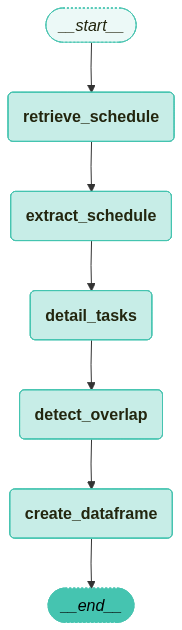

📊 워크플로우 시각화 완료


In [7]:
# 🔄 6. LangGraph 워크플로우 구성 및 컴파일

# 워크플로우 생성
workflow = StateGraph(ScheduleState)

# 노드 추가
workflow.add_node("retrieve_schedule", retrieve_schedule_node)
workflow.add_node("extract_schedule", extract_schedule_node)
workflow.add_node("detail_tasks", detail_tasks_node)
workflow.add_node("detect_overlap", detect_overlap_node)
workflow.add_node("create_dataframe", create_dataframe_node)

# 워크플로우 연결 (세분화 노드 추가)
workflow.add_edge(START, "retrieve_schedule")
workflow.add_edge("retrieve_schedule", "extract_schedule")
workflow.add_edge("extract_schedule", "detail_tasks")
workflow.add_edge("detail_tasks", "detect_overlap")
workflow.add_edge("detect_overlap", "create_dataframe")
workflow.add_edge("create_dataframe", END)

# 워크플로우 컴파일
schedule_app = workflow.compile()

print("✅ LangGraph 워크플로우 구성 및 컴파일 완료 (세분화 기능 포함)")
print("🔄 워크플로우: START → retrieve_schedule → extract_schedule → detail_tasks → detect_overlap → create_dataframe → END")

# 워크플로우 시각화
try:
    visualize_graph(schedule_app)
    print("📊 워크플로우 시각화 완료")
except Exception as e:
    print(f"⚠️ 워크플로우 시각화 실패: {e}")


In [8]:
# 🎯 7. 재배 일정표 생성 및 출력 함수 (세분화 기능 포함)

def generate_crop_schedule(crop: str) -> Dict[str, Any]:
    """작물별 재배 일정표를 생성하는 함수 (세분화 기능 포함)"""
    print(f"\n🌱 {crop.upper()} 재배 일정표 생성 (세분화 포함)")
    print("=" * 60)
    
    # 초기 상태 설정
    initial_state = {
        "crop": crop,
        "documents": [],
        "schedules": [],
        "detailed_tasks": [],
        "overlaps": [],
        "main_df": None,
        "detailed_df": None,
        "overlap_df": None,
        "status": "initialized",
        "error_message": None
    }
    
    try:
        # 워크플로우 실행
        result = schedule_app.invoke(initial_state)
        
        return result
        
    except Exception as e:
        print(f"❌ {crop} 일정표 생성 실패: {e}")
        return {
            **initial_state,
            "status": "error",
            "error_message": f"워크플로우 실행 실패: {str(e)}"
        }

def display_schedule(result: Dict[str, Any]):
    """생성된 일정표를 표시하는 함수 (세분화 기능 포함)"""
    crop = result.get("crop", "unknown")
    crop_name = "딸기" if crop == "strawberry" else "토마토"
    
    print(f"\n📅 {crop_name} 재배 일정표 (세분화 포함)")
    print("=" * 60)
    
    # 상태 확인
    status = result.get("status", "unknown")
    if status == "error":
        print(f"❌ 오류 발생: {result.get('error_message', '알 수 없는 오류')}")
        return
    
    # 메인 일정표 표시
    main_df = result.get("main_df")
    if main_df is not None and not main_df.empty:
        print("\n📋 메인 재배 일정표:")
        print("-" * 40)
        print(main_df.to_string(index=False))
    else:
        print("\n⚠️ 메인 일정표가 생성되지 않았습니다.")
    
    # 세분화된 작업표 표시 (월별 세분화)
    detailed_df = result.get("detailed_df")
    if detailed_df is not None and not detailed_df.empty:
        print(f"\n🔧 월별 세분화된 작업표 ({len(detailed_df)}개 항목):")
        print("-" * 40)
        print(detailed_df.to_string(index=False))
    else:
        print("\n⚠️ 월별 세분화된 작업표가 생성되지 않았습니다.")
    
    # 겹치는 일정 표시
    overlap_df = result.get("overlap_df")
    if overlap_df is not None and not overlap_df.empty:
        print(f"\n⚠️ 겹치는 일정 ({len(overlap_df)}개):")
        print("-" * 40)
        print(overlap_df.to_string(index=False))
    else:
        print("\n✅ 겹치는 일정이 없습니다.")
    
    # 처리 정보 표시
    print(f"\n📊 처리 정보:")
    print(f"   - 상태: {status}")
    print(f"   - 검색된 문서: {len(result.get('documents', []))}개")
    print(f"   - 추출된 일정: {len(result.get('schedules', []))}개")
    print(f"   - 세분화된 작업: {len(result.get('detailed_tasks', []))}개")
    print(f"   - 겹치는 일정: {len(result.get('overlaps', []))}개")

print("✅ 재배 일정표 생성 및 출력 함수 정의 완료 (세분화 기능 포함)")


✅ 재배 일정표 생성 및 출력 함수 정의 완료 (세분화 기능 포함)


In [9]:
# 📄 9. HTML 및 JSON 저장 기능 (모듈 import 방식)

# 모듈 import
from schedule_html_exporter import ScheduleExporter, export_schedule_both

# 전역 변수를 모듈에 전달
import schedule_html_exporter
schedule_html_exporter.USER_FARM_INFO = USER_FARM_INFO

# 또는 개별 함수 import
# from schedule_html_exporter import export_schedule_to_html, export_schedule_to_json

def select_crop():
    """사용자가 작물을 선택하는 함수"""
    print("\n🌱 재배 일정표를 생성할 작물을 선택해주세요")
    print("=" * 50)
    
    available_crops = {
        "1": {"code": "strawberry", "name": "딸기", "description": "딸기 재배 일정표"},
        "2": {"code": "tomato", "name": "토마토", "description": "토마토 재배 일정표"}
    }
    
    while True:
        print("\n📋 사용 가능한 작물:")
        for key, crop in available_crops.items():
            print(f"   {key}. {crop['name']} - {crop['description']}")
        
        print("\n선택 옵션:")
        print("   - 1: 딸기")
        print("   - 2: 토마토")
        print("   - all: 모든 작물 (딸기, 토마토)")
        print("   - quit: 종료")
        
        choice = input("\n작물을 선택하세요 (1/2/all/quit): ").strip().lower()
        
        if choice in available_crops:
            selected_crop = available_crops[choice]
            print(f"\n✅ {selected_crop['name']}이 선택되었습니다.")
            return selected_crop['code']
        elif choice == "all":
            print("\n✅ 모든 작물이 선택되었습니다.")
            return "all"
        elif choice in ["quit", "q", "종료"]:
            print("\n👋 프로그램을 종료합니다.")
            return None
        else:
            print("❌ 잘못된 선택입니다. 다시 입력해주세요.")
            continue

def get_crop_display_name(crop_code):
    """작물 코드를 표시명으로 변환 (하드코딩 제거)"""
    # result 데이터에서 crop_name이 있으면 사용, 없으면 crop_code 그대로 사용
    return crop_code

def main_schedule_generator():
    """메인 재배 일정표 생성 함수 (모듈화된 저장 기능 사용 + 월별 세분화 기능)"""
    print("🌱 작물 재배 일정표 생성 시스템 (월별 세분화 기능 포함)")
    print("=" * 80)
    print("📋 주요 기능:")
    print("   - 벡터스토어 검색을 통한 재배 일정 추출")
    print("   - 월별 세분화된 작업 정보 제공")
    print("   - 위치 정보를 고려한 맞춤형 일정표 생성")
    print("   - HTML/JSON 형식으로 결과 저장")
    print("=" * 80)
    
    # 1. 경작지 위치 설정 (선택사항)
    print("\n📍 경작지 위치 설정 (선택사항)")
    print("=" * 50)
    print("경작지 위치를 설정하면 더 정확한 농업 정보를 제공할 수 있습니다.")
    print("건너뛰려면 'skip' 또는 '건너뛰기'를 입력하세요.")
    
    user_choice = input("\n경작지 위치를 설정하시겠습니까? (y/n/skip): ").lower().strip()
    
    if user_choice in ['y', 'yes', '예', 'ㅇ']:
        print("\n📍 경작지 위치 설정을 시작합니다...")
        farm_info = setup_farm_location()
        if farm_info:
            print(f"\n✅ 경작지 위치 설정 완료: {farm_info['road_address']}")
            # 전역 변수 업데이트
            schedule_html_exporter.USER_FARM_INFO = farm_info
        else:
            print("\n❌ 경작지 위치 설정이 취소되었습니다.")
    elif user_choice in ['skip', '건너뛰기', 's']:
        print("\n⏭️ 경작지 위치 설정을 건너뜁니다.")
    else:
        print("\n⏭️ 경작지 위치 설정을 건너뜁니다.")
    
    print("\n" + "="*80)
    
    # 2. 작물 선택
    selected_crop = select_crop()
    
    if selected_crop is None:
        print("👋 프로그램을 종료합니다.")
        return
    
    print("\n" + "="*80)
    
    # 3. 재배 일정표 생성 및 파일 저장
    if selected_crop == "all":
        # 모든 작물 생성
        crops = ["strawberry", "tomato"]
        results = {}
        saved_files = []
        
        for crop in crops:
            print(f"\n🌱 {get_crop_display_name(crop).upper()} 재배 일정표 생성 중...")
            result = generate_crop_schedule(crop)
            display_schedule(result)
            results[crop] = result
            
            # HTML 및 JSON 저장 (모듈 사용)
            html_file, json_file = export_schedule_both(result)
            saved_files.append((html_file, json_file))
            
            if crop != crops[-1]:  # 마지막이 아니면 구분선
                print("\n" + "="*80)
        
        # 결과 요약
        print(f"\n📊 전체 테스트 결과 요약:")
        for crop, result in results.items():
            status = "✅ 성공" if result.get('status') == 'completed' else "❌ 실패"
            print(f"   - {get_crop_display_name(crop)} 일정표: {status}")
        
        print(f"\n📄 생성된 파일들:")
        for i, (html_file, json_file) in enumerate(saved_files):
            crop_name = get_crop_display_name(crops[i])
            print(f"   - {crop_name}: {html_file}, {json_file}")
        
        # 전역 변수로 저장 (세분화 기능 포함)
        strawberry_schedule_df = results.get('strawberry', {}).get('main_df')
        tomato_schedule_df = results.get('tomato', {}).get('main_df')
        strawberry_detailed_df = results.get('strawberry', {}).get('detailed_df')
        tomato_detailed_df = results.get('tomato', {}).get('detailed_df')
        strawberry_overlap_df = results.get('strawberry', {}).get('overlap_df')
        tomato_overlap_df = results.get('tomato', {}).get('overlap_df')
        
    else:
        # 선택된 작물만 생성
        print(f"\n🌱 {get_crop_display_name(selected_crop).upper()} 재배 일정표 생성 중...")
        result = generate_crop_schedule(selected_crop)
        display_schedule(result)
        
        # HTML 및 JSON 저장 (모듈 사용)
        html_file, json_file = export_schedule_both(result)
        
        print(f"\n📄 생성된 파일들:")
        print(f"   - HTML: {html_file}")
        print(f"   - JSON: {json_file}")
        
        # 전역 변수로 저장 (세분화 기능 포함)
        if selected_crop == "strawberry":
            strawberry_schedule_df = result.get('main_df')
            strawberry_detailed_df = result.get('detailed_df')
            strawberry_overlap_df = result.get('overlap_df')
            tomato_schedule_df = None
            tomato_detailed_df = None
            tomato_overlap_df = None
        elif selected_crop == "tomato":
            tomato_schedule_df = result.get('main_df')
            tomato_detailed_df = result.get('detailed_df')
            tomato_overlap_df = result.get('overlap_df')
            strawberry_schedule_df = None
            strawberry_detailed_df = None
            strawberry_overlap_df = None
    
    print("\n" + "="*80)
    print("🎉 작물 재배 일정표 생성 완료!")
    
    # 위치 정보 요약
    farm_info = get_farm_info()
    if farm_info:
        print(f"\n📍 설정된 경작지: {farm_info['road_address']}")
    else:
        print(f"\n📍 경작지 정보: 설정되지 않음")
    
    # 생성된 DataFrame 정보 출력 (월별 세분화 포함)
    print(f"\n💾 생성된 DataFrame들:")
    if strawberry_schedule_df is not None:
        print(f"   - 딸기 메인 일정표: {type(strawberry_schedule_df)} ({len(strawberry_schedule_df)}행)")
    if tomato_schedule_df is not None:
        print(f"   - 토마토 메인 일정표: {type(tomato_schedule_df)} ({len(tomato_schedule_df)}행)")
    if strawberry_detailed_df is not None and not strawberry_detailed_df.empty:
        print(f"   - 딸기 월별 세분화 작업표: {type(strawberry_detailed_df)} ({len(strawberry_detailed_df)}행)")
    if tomato_detailed_df is not None and not tomato_detailed_df.empty:
        print(f"   - 토마토 월별 세분화 작업표: {type(tomato_detailed_df)} ({len(tomato_detailed_df)}행)")
    if strawberry_overlap_df is not None and not strawberry_overlap_df.empty:
        print(f"   - 딸기 겹침 일정표: {type(strawberry_overlap_df)} ({len(strawberry_overlap_df)}행)")
    if tomato_overlap_df is not None and not tomato_overlap_df.empty:
        print(f"   - 토마토 겹침 일정표: {type(tomato_overlap_df)} ({len(tomato_overlap_df)}행)")
    
    print(f"\n✅ 선택된 작물의 결과가 전역 변수로 저장되었습니다:")
    if selected_crop == "strawberry":
        print(f"   - strawberry_schedule_df: 딸기 메인 일정표")
        print(f"   - strawberry_overlap_df: 딸기 겹침 일정표")
    elif selected_crop == "tomato":
        print(f"   - tomato_schedule_df: 토마토 메인 일정표")
        print(f"   - tomato_overlap_df: 토마토 겹침 일정표")
    elif selected_crop == "all":
        print(f"   - strawberry_schedule_df: 딸기 메인 일정표")
        print(f"   - tomato_schedule_df: 토마토 메인 일정표")
        print(f"   - strawberry_overlap_df: 딸기 겹침 일정표")
        print(f"   - tomato_overlap_df: 토마토 겹침 일정표")

print("✅ 모듈화된 HTML/JSON 저장 기능이 추가되었습니다.")

# 메인 함수 실행
if __name__ == "__main__":
    main_schedule_generator()

✅ 모듈화된 HTML/JSON 저장 기능이 추가되었습니다.
🌱 작물 재배 일정표 생성 시스템 (월별 세분화 기능 포함)
📋 주요 기능:
   - 벡터스토어 검색을 통한 재배 일정 추출
   - 월별 세분화된 작업 정보 제공
   - 위치 정보를 고려한 맞춤형 일정표 생성
   - HTML/JSON 형식으로 결과 저장

📍 경작지 위치 설정 (선택사항)
경작지 위치를 설정하면 더 정확한 농업 정보를 제공할 수 있습니다.
건너뛰려면 'skip' 또는 '건너뛰기'를 입력하세요.

📍 경작지 위치 설정을 시작합니다...
🌱 경작지 위치 설정

📍 경작지 주소를 입력해주세요:
예시: 서울시 강남구 테헤란로 123, 전라남도 순천시 중앙로 255
      또는: 순천대학교, 서울시청, 강남역 등

🔍 입력된 주소: 전남 순천시 중앙로 255
📍 주소를 좌표로 변환하고 정확한 주소를 확인하는 중...

✅ 주소 변환 완료!
📋 확인된 정보:
   입력 주소: 전남 순천시 중앙로 255
   좌표: 127.4809015, 34.9689183
   도로명 주소: 전라남도 순천시 중앙로 255
   법정동 주소: 전라남도 순천시 석현동

🎉 경작지 위치 설정 완료!
📍 설정된 위치: 전라남도 순천시 중앙로 255
📍 좌표: 127.4809015, 34.9689183

✅ 경작지 위치 설정 완료: 전라남도 순천시 중앙로 255


🌱 재배 일정표를 생성할 작물을 선택해주세요

📋 사용 가능한 작물:
   1. 딸기 - 딸기 재배 일정표
   2. 토마토 - 토마토 재배 일정표

선택 옵션:
   - 1: 딸기
   - 2: 토마토
   - all: 모든 작물 (딸기, 토마토)
   - quit: 종료

✅ 모든 작물이 선택되었습니다.


🌱 STRAWBERRY 재배 일정표 생성 중...

🌱 STRAWBERRY 재배 일정표 생성 (세분화 포함)
==== [RETRIEVE SCHEDULE] strawberry ====
📍 위치 정보가 포함된 검색 쿼리 사용
🔍 검색 쿼리: 딸기 

# 📋 재배 일정표 생성 시스템 사용 가이드 (세분화 기능 포함)

## 🌟 주요 기능

### 1. **기본 재배 일정표 생성**
- 벡터스토어 검색을 통한 작물별 재배 일정 추출
- 월별 농작업 일정표 생성
- 겹치는 일정 자동 감지 및 표시

### 2. **작업 세분화 기능** ⭐ **NEW**
- 각 재배 작업을 월별로 세분화하여 상세 분석
- 구체적인 작업 방법, 주의사항, 도구/자재 정보 제공
- 환경 조건, 작업 빈도, 소요 시간 등 상세 정보 포함
- 월별 작업 순서와 연속성 고려

### 3. **위치 정보 활용**
- 사용자 경작지 위치 등록
- 지역별 기후 특성을 고려한 맞춤형 일정표 생성
- 지오코딩을 통한 정확한 위치 정보 처리

### 4. **다양한 출력 형식**
- **HTML**: 시각적으로 보기 좋은 웹 페이지 형식
- **JSON**: 구조화된 데이터로 프로그래밍 활용 가능
- **DataFrame**: pandas를 통한 데이터 분석 및 조작

## 🚀 사용 방법

### **실행 방법**
```python
# Cell 9: 월별 세분화 기능 테스트
# Cell 10: 실제 실행 코드
main_schedule_generator()
```

### **개별 함수 사용**
```python
# 특정 작물만 생성
result = generate_crop_schedule("strawberry")
display_schedule(result)
```

## 📊 출력 데이터 구조

### **메인 일정표**
- 기간, 작업명, 상세내용

### **세분화된 작업표** ⭐ **NEW**
- 작업명, 월, 세부작업, 기간, 설명
- 작업방법, 주의사항, 도구/자재
- 환경조건, 작업빈도, 소요시간
- 월별 순서로 정렬된 상세 작업 정보

### **겹침 일정표**
- 기간, 작업1, 작업2, 비고

## 🔧 기술 스택

- **LangChain**: LLM 통합 및 프롬프트 관리
- **LangGraph**: 워크플로우 관리 및 상태 처리
- **OpenAI**: 언어 모델 및 임베딩
- **Cohere**: 문서 리랭킹 (선택사항)
- **Pandas**: 데이터 처리 및 분석
- **Pydantic**: 데이터 검증 및 구조화

## 📁 생성되는 파일

- `{작물명}_hybrid_calendar_{timestamp}.html`: 시각적 일정표
- `{작물명}_hybrid_calendar_{timestamp}.json`: 구조화된 데이터

## ⚠️ 주의사항

1. **API 키 설정**: OpenAI API 키가 필요합니다
2. **인터넷 연결**: 벡터스토어 검색 및 LLM 호출을 위해 필요합니다
3. **데이터 품질**: PDF 문서의 품질에 따라 결과가 달라질 수 있습니다
4. **위치 정보**: 정확한 위치 정보를 입력하면 더 나은 결과를 얻을 수 있습니다

## 🎯 활용 예시

### **농업 계획 수립**
- 월별 농작업 계획 수립
- 작업 우선순위 결정
- 자원 배분 계획

### **작업 관리**
- 세부 작업 방법 확인
- 필요한 도구/자재 준비
- 작업 일정 관리

### **교육 및 학습**
- 재배 기술 학습
- 농업 지식 습득
- 실무 가이드 활용

## 🔄 실행 순서

1. **Cell 1-7**: 환경 설정 및 함수 정의
2. **Cell 8**: 메인 함수 정의
3. **Cell 9**: 월별 세분화 기능 테스트
4. **Cell 10**: 실제 실행 코드
5. **Cell 11**: 사용 가이드


# 📋 작물 재배 일정표 생성 시스템 완료

## 🎯 구현 완료 사항

✅ **환경 설정 및 모듈 Import**
- LangChain, LangGraph, pandas 등 필수 라이브러리 import
- OpenAI 모델 및 임베딩 모델 초기화
- Cohere 리랭커 설정 (선택적)

✅ **RAG 시스템 초기화**
- PDFRetrievalChain을 활용한 벡터스토어 설정
- 딸기/토마토 PDF 데이터 경로 구성
- 통합 벡터스토어 연결 (db/crop_vector)

✅ **LangGraph State 정의**
- ScheduleState 클래스 정의
- Pydantic 모델 (ScheduleItem, ScheduleList) 정의
- 상태 관리 구조 완성

✅ **노드 함수 구현**
- `retrieve_schedule_node`: 재배 일정 관련 문서 검색
- `extract_schedule_node`: LLM을 통한 일정 정보 추출 및 구조화
- `detect_overlap_node`: 겹치는 일정 감지
- `create_dataframe_node`: DataFrame 생성 및 정렬

✅ **워크플로우 구성**
- LangGraph 워크플로우 구성 및 컴파일
- 워크플로우 시각화
- 순차적 처리 파이프라인 완성

✅ **테스트 및 출력**
- 딸기와 토마토 재배 일정표 생성 테스트
- DataFrame 형식으로 표시
- 겹치는 일정 별도 섹션으로 분리

## 🔧 주요 기능

1. **자동 문서 검색**: 벡터스토어에서 재배 일정 관련 문서 자동 검색
2. **지능적 정보 추출**: LLM을 통한 구조화된 일정 정보 추출
3. **겹침 감지**: 같은 월에 여러 작업이 있는 경우 자동 감지
4. **표 형식 출력**: pandas DataFrame으로 정리된 일정표 제공
5. **에러 처리**: 각 단계별 에러 처리 및 대체 방안 제공

## 📊 출력 형식

- **메인 일정표**: 기간, 작업명, 상세내용 컬럼으로 구성
- **겹침 일정표**: 기간, 작업1, 작업2, 비고 컬럼으로 구성
- **월별 정렬**: 1월부터 12월 순서로 자동 정렬

## 🚀 사용 방법

```python
# 딸기 재배 일정표 생성
strawberry_result = generate_crop_schedule("strawberry")
display_schedule(strawberry_result)

# 토마토 재배 일정표 생성
tomato_result = generate_crop_schedule("tomato")
display_schedule(tomato_result)
```

## 📁 관련 파일

- **구현 파일**: `calendar format re/schedule.ipynb`
- **참고 파일**: `calendar format re/langraph.ipynb`
- **재사용 모듈**: `calendar format re/rag/pdf.py`
- **벡터스토어**: `calendar format re/db/crop_vector/`
